### Plot by Water Year (WY) Using a Function to clean this up

Notebook contents 
* All data downloaded from Synoptic Weather API, + Heen SNOTEL

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **xarray**

In [44]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib 

In [45]:
pwd

'/home/cassie/python/repos/snowdepth_teleconnections'

### Load Data 

#### Load CSV created in script `3_clean_snowdepth...`

In [46]:
# save the df dataframe to a csv file
# df.to_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_ppsa_tram_heen_2015_2026.csv')

# load the saved csv file back into a dataframe
df = pd.read_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_ppsa_tram_heen_2015_2026.csv', index_col=0, parse_dates=True)
df.head()

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth
datetime,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.268408
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.261541
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.254677
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.247814
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.240953


### Compute Day of Water Year, Water Year, etc.

In [75]:
# Minimal time prep needed for smoothing (no WY plotting fields here).
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
else:
    df['datetime'] = pd.to_datetime(df.index)

# Standardize Powder Patch naming to 4-char station code.
if 'ppsa' not in df.columns and 'powderpatch' in df.columns:
    df = df.rename(columns={'powderpatch': 'ppsa'})
elif 'ppsa' not in df.columns:
    raise ValueError("Expected 'ppsa' or 'powderpatch' column in df.")

# Remove legacy pp_* smooth columns if present to avoid naming confusion.
legacy_pp_cols = [c for c in df.columns if c.startswith('pp_smooth_')]
if legacy_pp_cols:
    df = df.drop(columns=legacy_pp_cols)

# Continuous time axis for LOWESS input
first_date = df['datetime'].min()
df['day_since_first_wy'] = (df['datetime'] - first_date).dt.days

df[['datetime', 'day_since_first_wy', 'ppsa']].head()
df.head()

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth,datetime,day_since_first_wy,heen_smooth_001,heen_smooth_002,heen_smooth_005,tram_smooth_001,tram_smooth_002,tram_smooth_005,ppsa,ppsa_smooth_001,ppsa_smooth_002,ppsa_smooth_005
datetime,,,,,,,,,,,,,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.268408,2015-10-01 00:00:00,0,0.0,0.0,0.0,4.360763,4.390805,4.202372,NaN,NaN,NaN,NaN
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.261541,2015-10-01 01:00:00,0,0.0,0.0,0.0,4.360763,4.390805,4.202372,NaN,NaN,NaN,NaN
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.254677,2015-10-01 02:00:00,0,0.0,0.0,0.0,4.360763,4.390805,4.202372,NaN,NaN,NaN,NaN
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.247814,2015-10-01 03:00:00,0,0.0,0.0,0.0,4.360763,4.390805,4.202372,NaN,NaN,NaN,NaN
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.240953,2015-10-01 04:00:00,0,0.0,0.0,0.0,4.360763,4.390805,4.202372,NaN,NaN,NaN,NaN


#### LOWESS Smoothing - moving it back here 

In [ ]:
# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df_snow_smooth['ppsa_smooth_001'] = lowess(
    endog=df_snow_smooth['ppsa'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df_snow_smooth['ppsa_smooth_002'] = lowess(
    endog=df_snow_smooth['ppsa'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df_snow_smooth['ppsa_smooth_005'] = lowess(
    endog=df_snow_smooth['ppsa'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df_snow_smooth['heen_smooth_001'] = lowess(
    endog=df_snow_smooth['snotel'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df_snow_smooth['heen_smooth_002'] = lowess(
    endog=df_snow_smooth['snotel'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df_snow_smooth['heen_smooth_005'] = lowess(
    endog=df_snow_smooth['snotel'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df_snow_smooth['tram_smooth_001'] = lowess(
    endog=df_snow_smooth['tram'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df_snow_smooth['tram_smooth_002'] = lowess(
    endog=df_snow_smooth['tram'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df_snow_smooth['tram_smooth_005'] = lowess(
    endog=df_snow_smooth['tram'],
    exog=df_snow_smooth['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

## Plot by Water Year (WY)

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

In [73]:
def plot_snowdepth_by_wateryear(
    df,
    depth_col='ppsa_smooth_001',
    highlight_wy=None,
    other_years_style='grey',
    cmap_name='turbo',
    figsize=(14, 6),
    title='Snow Depth Observations at Powder Patch',
):
    """
    Plot snow depth by water year with one highlighted year in black.

    The function computes plotting fields internally:
    - wy: water year (Sep-Aug)
    - wy_day: day of water year, starting at 1 on Sep 1
    """

    if depth_col not in df.columns:
        raise ValueError(f"Missing required column: {depth_col}")

    # Build a local plotting dataframe so upstream notebook cells stay minimal.
    plot_df = df[[depth_col]].copy()

    if 'datetime' in df.columns:
        plot_df['dt'] = pd.to_datetime(df['datetime'])
    else:
        plot_df['dt'] = pd.to_datetime(df.index)

    plot_df = plot_df.dropna(subset=[depth_col, 'dt']).copy()
    if plot_df.empty:
        raise ValueError('No valid rows available for plotting after dropping NaNs.')

    # Compute water-year fields only inside this function.
    plot_df['wy'] = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year + 1,
        plot_df['dt'].dt.year,
    ).astype(int)

    wy_start_year = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year,
        plot_df['dt'].dt.year - 1,
    )
    wy_start = pd.to_datetime({'year': wy_start_year, 'month': 9, 'day': 1})
    wy_day = (plot_df['dt'].to_numpy() - wy_start.to_numpy()) / np.timedelta64(1, 'D')
    plot_df['wy_day'] = np.floor(wy_day).astype(int) + 1

    water_years = sorted(plot_df['wy'].unique())
    if not water_years:
        raise ValueError('No water years available to plot.')

    if highlight_wy is None:
        user_input = input(f"Enter a water year to highlight in black {water_years}: ")
        try:
            highlight_wy = int(user_input)
        except ValueError as exc:
            raise ValueError('Water year must be an integer.') from exc

    if highlight_wy not in water_years:
        raise ValueError(f"highlight_wy={highlight_wy} not found. Options: {water_years}")

    if other_years_style not in {'grey', 'colorscale'}:
        raise ValueError("other_years_style must be 'grey' or 'colorscale'.")

    fig, ax_in = plt.subplots(figsize=figsize)

    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

    for year in water_years:
        if year == highlight_wy:
            continue

        year_data = plot_df[plot_df['wy'] == year]

        if other_years_style == 'grey':
            color = 'lightgrey'
            alpha = 0.8
        else:
            color = cmap(norm(year))
            alpha = 0.55

        ax_in.scatter(
            year_data['wy_day'],
            year_data[depth_col],
            color=color,
            alpha=alpha,
            s=10,
            edgecolors='none',
        )

    highlight_data = plot_df[plot_df['wy'] == highlight_wy]
    ax_in.plot(
        highlight_data['wy_day'],
        highlight_data[depth_col],
        color='black',
        linewidth=2.5,
        label=f'WY {highlight_wy}',
    )

    mean_by_day = (
        plot_df.groupby('wy_day')[depth_col]
        .mean()
        .sort_index()
    )
    ax_in.plot(
        mean_by_day.index,
        mean_by_day.values,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='Mean',
    )

    # Month ticks for Sep-Aug on WY day axis (1-based).
    tick_dates = [pd.Timestamp(2001, m, 1) for m in range(9, 13)] + [
        pd.Timestamp(2002, m, 1) for m in range(1, 9)
    ]
    wy0 = pd.Timestamp(2001, 9, 1)
    tick_locs = [(d - wy0).days + 1 for d in tick_dates]
    tick_labels = [d.strftime('%b') for d in tick_dates]

    ax_in.set_xticks(tick_locs)
    ax_in.set_xticklabels(tick_labels)
    ax_in.set_xlabel('Day of Water Year (Sep-Aug)')

    ax_in.set_ylabel('snow depth (inches)')
    ax_in.set_ylim(-5, 205)

    ax_cm = ax_in.twinx()
    inch_to_cm = 2.54
    ymin, ymax = ax_in.get_ylim()
    ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
    ax_cm.set_ylabel('snow depth (cm)')

    ax_cm.yaxis.set_label_position('right')
    ax_cm.yaxis.tick_right()
    ax_in.yaxis.tick_left()
    ax_in.yaxis.set_label_position('left')
    ax_cm.grid(False)

    ax_in.set_title(title)
    ax_in.grid(True, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], color='black', lw=2.5, label=f'WY {highlight_wy}'),
        Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Mean'),
    ]

    if other_years_style == 'grey':
        legend_elements.insert(
            0,
            Line2D(
                [0], [0], marker='o', color='w', markerfacecolor='lightgrey',
                markersize=7, label='Other years'
            ),
        )
    else:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax_in, pad=0.02)
        cbar.set_label('Water Year (other years)')

    ax_in.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    plt.show()


## Example calls:
## 1) Prompt for highlighted WY, with all other years in grey
# plot_snowdepth_by_wateryear(df, depth_col='ppsa_smooth_001', other_years_style='grey')

## 2) Explicit highlight year, with all other years on a colorscale
## plot_snowdepth_by_wateryear(
##     df,
##     depth_col='ppsa_smooth_001',
##     highlight_wy=2025,
##     other_years_style='colorscale',
##     cmap_name='turbo',
## )

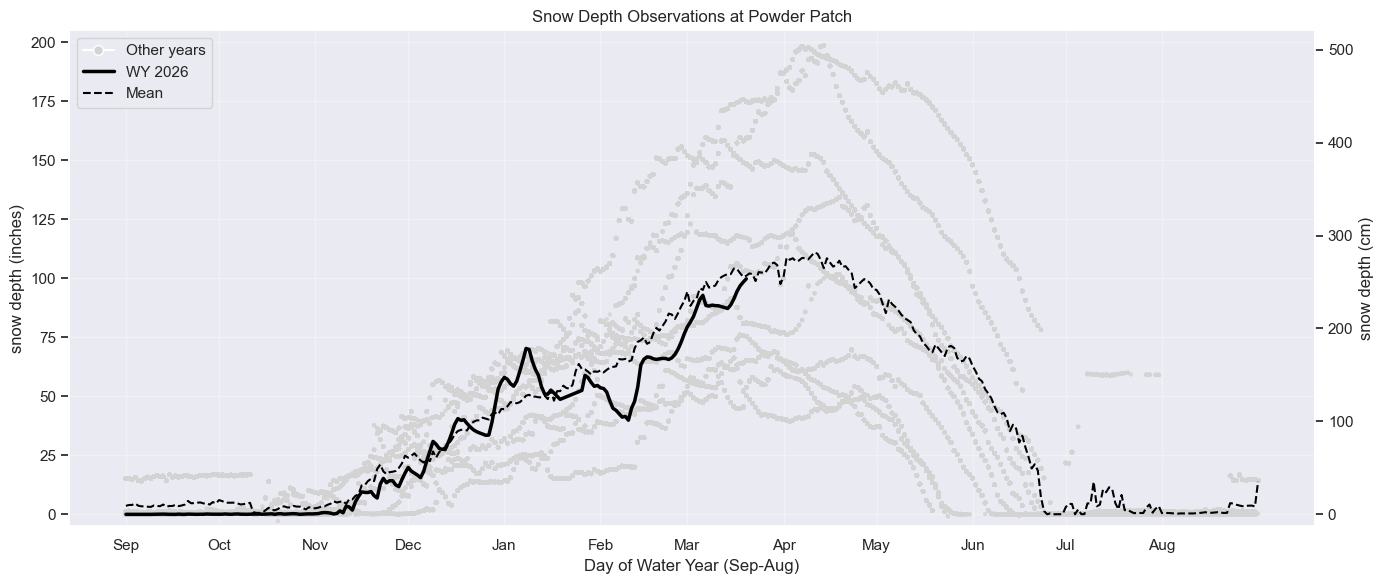

In [77]:
## Example calls:
## 1) Prompt for highlighted WY, with all other years in grey
plot_snowdepth_by_wateryear(df, depth_col='ppsa_smooth_001', highlight_wy=2026, other_years_style='grey')

## 2) Explicit highlight year, with all other years on a colorscale
# plot_snowdepth_by_wateryear(
#     df,
#     depth_col='ppsa_smooth_001',
#     highlight_wy=2025,
#     other_years_style='colorscale',
#     cmap_name='turbo',
# )

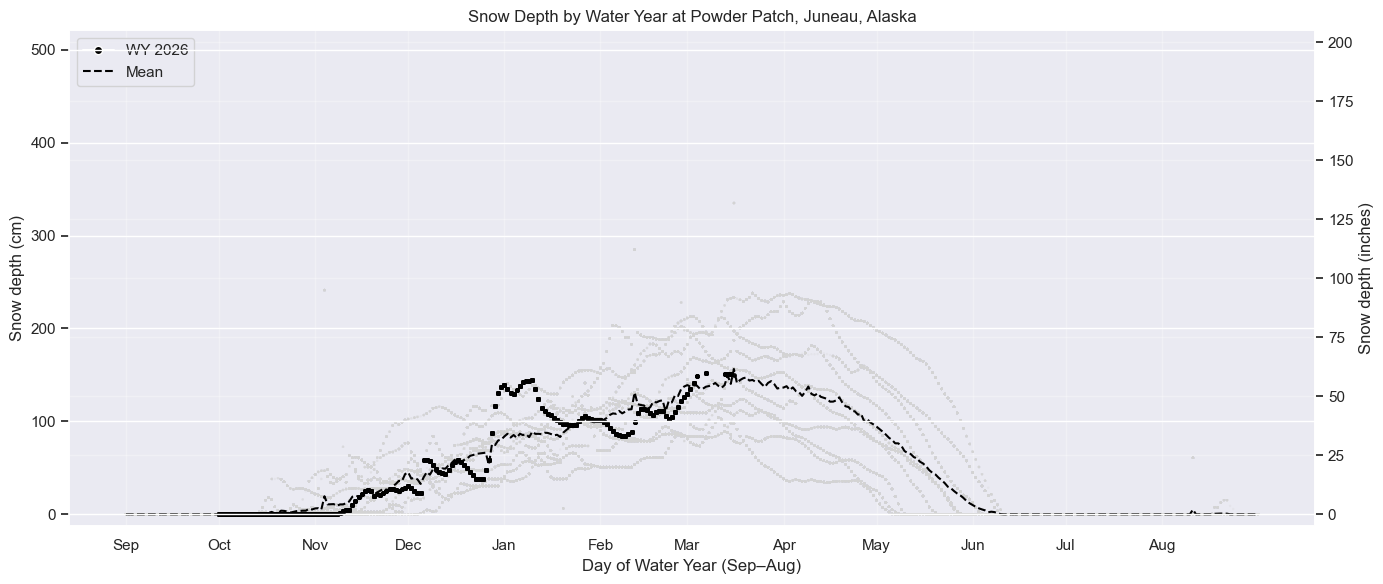

In [ ]:
depth_col = 'heen_smooth_001'

# -----------------------------
# Prepare data
# -----------------------------
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()
water_years = sorted(df_plot['water_year'].unique())

target_wy = max(water_years)  # assume 2026

# -----------------------------
# Figure + axes
# -----------------------------
fig, ax_in = plt.subplots(figsize=(14, 6))

# -----------------------------
# Background years (grey cloud)
# -----------------------------
for year in water_years:
    if year == target_wy:
        continue

    year_data = df_plot[df_plot['water_year'] == year]

    ax_in.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        color='lightgrey',
        alpha=0.25,     # ↓ key for readability
        s=3,            # slightly larger than 2 for visibility
        edgecolors='none'
    )

# -----------------------------
# Highlight WY 2026
# -----------------------------
year_data = df_plot[df_plot['water_year'] == target_wy]

ax_in.scatter(
    year_data['snow_year_day'],
    year_data[depth_col],
    color='black',
    alpha=0.9,
    s=6,
    label=f'WY {target_wy}',
    zorder=5   # ensures it's on top
)

# -----------------------------
# Mean line (dashed)
# -----------------------------
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

ax_in.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Mean',
    zorder=6
)

# -----------------------------
# X-axis formatting
# -----------------------------
tick_locs = []
tick_labels = []

for month in range(9, 13):
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b'))

for month in range(1, 9):
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b'))

ax_in.set_xticks(tick_locs)
ax_in.set_xticklabels(tick_labels)

# -----------------------------
# Y-axis (RIGHT: inches)
# -----------------------------
ax_in.set_ylabel('Snow depth (inches)')
ax_in.set_ylim(-5, 205)

# -----------------------------
# Y-axis (LEFT: cm)
# -----------------------------
ax_cm = ax_in.twinx()

inch_to_cm = 2.54
ymin, ymax = ax_in.get_ylim()

ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
ax_cm.set_ylabel('Snow depth (cm)')

# Move cm axis to LEFT
ax_cm.yaxis.set_label_position('left')
ax_cm.yaxis.tick_left()
ax_in.yaxis.tick_right()
ax_in.yaxis.set_label_position('right')

# -----------------------------
# Styling
# -----------------------------
ax_in.set_xlabel('Day of Water Year (Sep–Aug)')
ax_in.set_title('Snow Depth by Water Year at Powder Patch, Juneau, Alaska')

ax_in.grid(True, alpha=0.3)

# -----------------------------
# Legend (minimal + clean)
# -----------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markersize=6, label=f'WY {target_wy}'),
    Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='Mean')
]

ax_in.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
def plot_snowdepth_with_minmax_envelope(
    df,
    depth_col='ppsa_smooth_002',
    highlight_wy=None,
    figsize=(14, 6),
    title='Snow Depth Observations at the Tram',
):
    """
    Plot one highlighted water year plus a min-max envelope.

    Envelope logic: uses all water years from the minimum available WY
    up to and including the highlighted WY.

    The function computes plotting fields internally:
    - wy: water year (Sep-Aug)
    - wy_day: day of water year (Sep 1 = 1)
    """

    if depth_col not in df.columns:
        raise ValueError(f"Missing required column: {depth_col}")

    plot_df = df[[depth_col]].copy()
    if 'datetime' in df.columns:
        plot_df['dt'] = pd.to_datetime(df['datetime'])
    else:
        plot_df['dt'] = pd.to_datetime(df.index)

    plot_df = plot_df.dropna(subset=[depth_col, 'dt']).copy()
    if plot_df.empty:
        raise ValueError('No valid rows available for plotting after dropping NaNs.')

    plot_df['wy'] = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year + 1,
        plot_df['dt'].dt.year,
    ).astype(int)

    wy_start_year = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year,
        plot_df['dt'].dt.year - 1,
    )
    wy_start = pd.to_datetime({'year': wy_start_year, 'month': 9, 'day': 1})
    wy_day = (plot_df['dt'].to_numpy() - wy_start.to_numpy()) / np.timedelta64(1, 'D')
    plot_df['wy_day'] = np.floor(wy_day).astype(int) + 1

    water_years = sorted(plot_df['wy'].unique())
    if not water_years:
        raise ValueError('No water years available to plot.')

    if highlight_wy is None:
        user_input = input(f"Enter a water year to highlight in black {water_years}: ")
        try:
            highlight_wy = int(user_input)
        except ValueError as exc:
            raise ValueError('Water year must be an integer.') from exc

    if highlight_wy not in water_years:
        raise ValueError(f"highlight_wy={highlight_wy} not found. Options: {water_years}")

    envelope_df = plot_df[plot_df['wy'] <= highlight_wy].copy()
    grouped = envelope_df.groupby('wy_day')[depth_col]
    min_by_day = grouped.min().sort_index()
    max_by_day = grouped.max().sort_index()
    mean_by_day = grouped.mean().sort_index()

    fig, ax_in = plt.subplots(figsize=figsize)

    ax_in.fill_between(
        min_by_day.index,
        min_by_day.values,
        max_by_day.values,
        color='lightblue',
        alpha=0.7,
        label=f'Min-max range (WY {min(water_years)}-{highlight_wy})',
    )

    ax_in.plot(
        mean_by_day.index,
        mean_by_day.values,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='Mean',
    )

    year_data = plot_df[plot_df['wy'] == highlight_wy]
    ax_in.plot(
        year_data['wy_day'],
        year_data[depth_col],
        color='black',
        linewidth=2.5,
        label=f'WY {highlight_wy}',
    )

    tick_dates = [pd.Timestamp(2001, m, 1) for m in range(9, 13)] + [
        pd.Timestamp(2002, m, 1) for m in range(1, 9)
    ]
    wy0 = pd.Timestamp(2001, 9, 1)
    tick_locs = [(d - wy0).days + 1 for d in tick_dates]
    tick_labels = [d.strftime('%b') for d in tick_dates]

    ax_in.set_xticks(tick_locs)
    ax_in.set_xticklabels(tick_labels)
    ax_in.set_xlabel('Day of Water Year (Sep-Aug)')

    ax_in.set_ylabel('snow depth (inches)')
    ax_in.set_ylim(-5, 205)

    ax_cm = ax_in.twinx()
    inch_to_cm = 2.54
    ymin, ymax = ax_in.get_ylim()
    ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
    ax_cm.set_ylabel('snow depth (cm)')

    ax_cm.yaxis.set_label_position('right')
    ax_cm.yaxis.tick_right()
    ax_in.yaxis.tick_left()
    ax_in.yaxis.set_label_position('left')
    ax_cm.grid(False)

    ax_in.set_title(title)
    ax_in.grid(True, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], color='lightblue', lw=6, label=f'Min-max range (WY {min(water_years)}-{highlight_wy})'),
        Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='Mean'),
        Line2D([0], [0], color='black', lw=2.5, label=f'WY {highlight_wy}'),
    ]
    ax_in.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    plt.show()


## Example calls:
## 1) Prompt for highlighted WY
## plot_snowdepth_with_minmax_envelope(df, depth_col='tram_smooth_002')

## 2) Explicit highlight year
## plot_snowdepth_with_minmax_envelope(
##     df,
##     depth_col='tram_smooth_002',
##     highlight_wy=2024,
##     title='Snow Depth Observations at the Tram',
## )

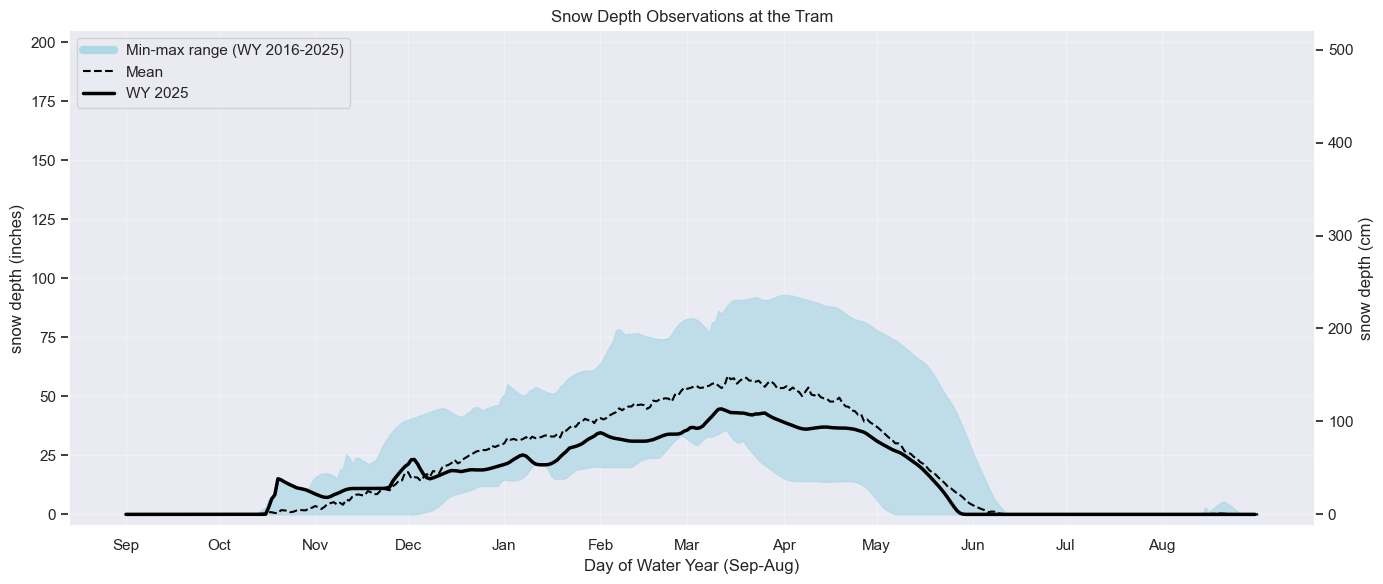

In [70]:
plot_snowdepth_with_minmax_envelope(
    df,
    depth_col='heen_smooth_002',
    highlight_wy=2025,
    title='Snow Depth Observations at the Tram',
)